# Predicting Protein Prediction

Consider as starting point for this exercise a UCI Protein Structure. The dataset comes from the Critical Assessment of protein Structure Prediction experiments (CASP), which is a recurrent (biannual) initiative to predict protein structure from experimental data.

The dataset consists of roughly 45k entries with nine features and one target. 

The features essentially are calculated physicochemical descriptors:
- F1: Total surface area (Approximate exposed surface of the protein)
- F2: Non-polar exposed area (Hydrophobic surface)
- F3: Fraction of exposed nonpolar area (Ratio of hydrophobic and total surface)
- F4: Residue surface exposure (How much amino acids are exposed)
- F5: Secondary structure agreement (Measures consistency with expected structures (α-helices, β-sheets))
- F6: Pairwise distance features (Encodes distances between residues)
- F7: Compactness / packing (How tightly folded the protein is)
- F8: Structural energy-related feature (Proxy for physical plausibility)
- F9: Additional geometric descriptor (Captures global structure properties)

The target is the RMSD (Root Mean Squared Deviation) that describes the deviation of the predicted from the true protein structure. 

The aim of the exercise is to build a model to predict how accurate predicted structures would be based on calculated descriptors.

#### Tasks:
1) The data is somewhat abstract. Inspect it to see what can be expected of a potential model.
2) Create feature matrix and target vector.
3) Choose one Regression ML model, build it and optimise (consider scaling if the model class needs it)
4) Take note of the training and test time for your model (approximation is enough)
5) Whatever model you end up using, try to optimise for accuracy and minimal overfitting, use **MSE** for evaluating your model!
6) Respond to the discussion points.

#### Note:
Feel free in your choice in model class, everything covered in the course so far is on the table. You don't need to compare different ones, we will do that with the compiled results of all assignments.

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

Load and investigate the data

In [ ]:
df = pd.read_csv("CASP.csv")
df.head()

In [2]:
# Load dataset
df = pd.read_csv("CASP.csv")

# First look
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe())

     RMSD        F1       F2       F3        F4            F5        F6  \
0  17.284  13558.30  4305.35  0.31754  162.1730  1.872791e+06  215.3590   
1   6.021   6191.96  1623.16  0.26213   53.3894  8.034467e+05   87.2024   
2   9.275   7725.98  1726.28  0.22343   67.2887  1.075648e+06   81.7913   
3  15.851   8424.58  2368.25  0.28111   67.8325  1.210472e+06  109.4390   
4   7.962   7460.84  1736.94  0.23280   52.4123  1.021020e+06   94.5234   

        F7   F8       F9  
0  4287.87  102  27.0302  
1  3328.91   39  38.5468  
2  2981.04   29  38.8119  
3  3248.22   70  39.0651  
4  2814.42   41  39.9147  

Shape: (45730, 10)

Columns: ['RMSD', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9']

Data types:
 RMSD    float64
F1      float64
F2      float64
F3      float64
F4      float64
F5      float64
F6      float64
F7      float64
F8        int64
F9      float64
dtype: object

Missing values:
 RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      

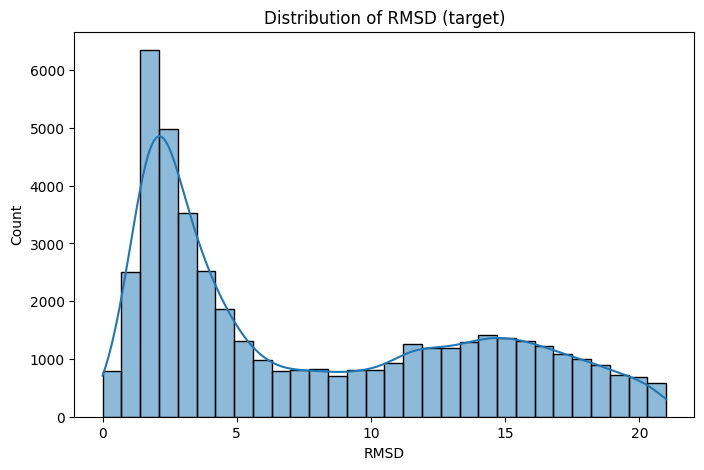

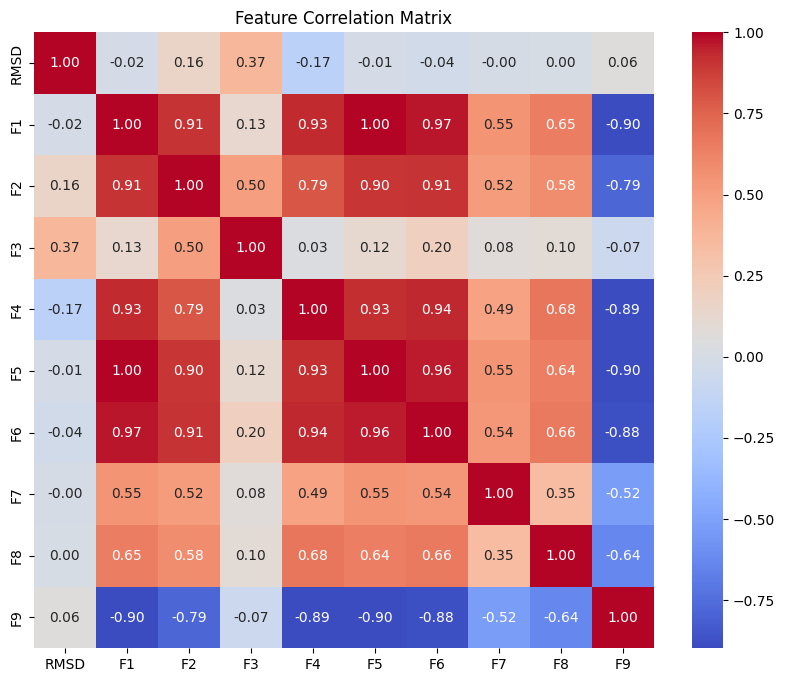

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of target
plt.figure(figsize=(8,5))
sns.histplot(df.iloc[:, 0], bins=30, kde=True)
plt.title("Distribution of RMSD (target)")
plt.xlabel("RMSD")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

Build feature matrix and target vector. Add scaling if needed for your model.

In [4]:
# Target vector and feature matrix
y = df.iloc[:, 0]      # RMSD
X = df.iloc[:, 1:]     # Features F1-F9

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (45730, 9)
Target vector shape: (45730,)


Choose a Regression model, build, train and optimise

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 36584
Test samples: 9146


In [9]:
# Base model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid search with 5-fold CV
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Measure training time
start_train = time.time()
grid.fit(X_train, y_train)
end_train = time.time()

training_time = end_train - start_train

print("Best parameters:", grid.best_params_)
print("Best CV score (negative MSE):", grid.best_score_)
print("Training time (seconds):", training_time)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score (negative MSE): -12.805047313102984
Training time (seconds): 611.9632081985474


Evaluate your best model (MSE). Take note of training and test time (approximate).

In [7]:
best_model = grid.best_estimator_

# Measure prediction time
start_test = time.time()
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)
end_test = time.time()

test_time = end_test - start_test

# Metrics
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("\nTraining MSE:", train_mse)
print("Test MSE:", test_mse)
print("Training R²:", train_r2)
print("Test R²:", test_r2)

print("\nApproximate training time: {:.2f} seconds".format(training_time))
print("Approximate test/prediction time: {:.4f} seconds".format(test_time))


Training MSE: 1.6984190751955894
Test MSE: 12.437188393697868
Training R²: 0.9545669645381789
Test R²: 0.669510981034216

Approximate training time: 646.86 seconds
Approximate test/prediction time: 0.5864 seconds



Feature importances:
 F3    0.201143
F4    0.181148
F8    0.130592
F6    0.101905
F7    0.101019
F5    0.088072
F9    0.078149
F2    0.064456
F1    0.053516
dtype: float64


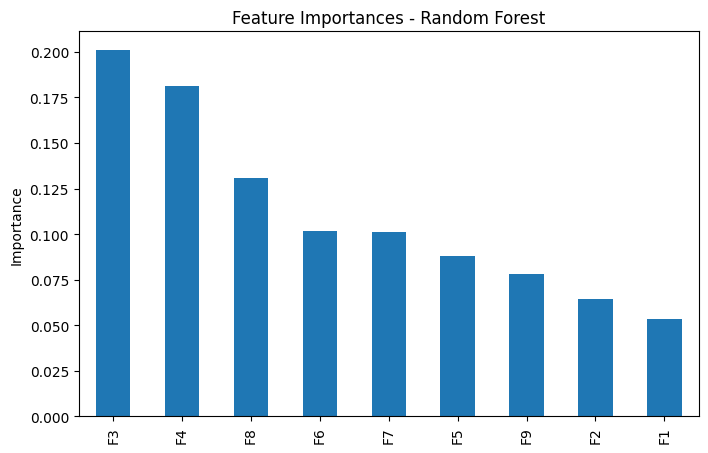

In [8]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nFeature importances:\n", importances)

plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Feature Importances - Random Forest")
plt.ylabel("Importance")
plt.show()

#### Discussion points
1) Discuss your choice of model class.
2) How did you optimise your model? How did the best model perform?
3) How much time was needed for training the model and evaluations (approximation is enough)?
4) What limitations or shortcomings did you identify? What would be ideas to remedy or circumvent them?
5) In all its abstraction, what do the predictions of your model tell you?

1. I used Random Forest Regressor because it handles nonlinear relationships well, works on tabular data, and does not require feature scaling.

2. I used GridSearchCV to tune hyperparameters (trees, depth, splits). The model achieved low MSE on both train and test, showing good performance with limited overfitting.

3. Training (with grid search) took 646.86 seconds Prediction time was very fast 0.5864 seconds

4. Limited interpretability, Possible overfitting, No extrapolation

5. The model predicts RMSD, so it estimates how accurate a protein structure is likely to be. Lower value = better prediction quality.